## Install and import nesscsecary libraries


In [1]:
!cd .. && pip install -r requirements.txt -q

In [2]:
import gc
import itertools
import os
from pathlib import Path
from pprint import pprint as pp

import accelerate
import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import ClassLabel, Dataset, Image
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    RandomRotation,
    RandomVerticalFlip,
    Resize,
    ToTensor,
)
from tqdm.notebook import tqdm, trange
from transformers import (
    DefaultDataCollator,
    Trainer,
    TrainingArguments,
    ViTForImageClassification,
    ViTImageProcessor,
)

## Load the image and label


In [3]:
data_dir = Path("../Dataset/images")
train_dir, valid_dir = data_dir.iterdir()
train_dir, valid_dir

(PosixPath('../Dataset/images/validation'),
 PosixPath('../Dataset/images/train'))

In [4]:
image_files = sorted(data_dir.glob("*/*/*.*"))
len(image_files)

35887

In [5]:
files, labels = [], []

for file in sorted(image_files):
    files.append(str(file))
    labels.append(file.parent.name)

print(len(files), len(labels))

35887 35887


In [6]:
df = pd.DataFrame.from_dict({"file": files, "label": labels})
print(df.shape)
df.head()

(35887, 2)


,file,label
0,../Dataset/images/train/angry/0.jpg,angry
1,../Dataset/images/train/angry/1.jpg,angry
2,../Dataset/images/train/angry/10.jpg,angry
3,../Dataset/images/train/angry/10002.jpg,angry
4,../Dataset/images/train/angry/10016.jpg,angry


## Random Oversampling of minority class


In [7]:
y = df["label"].values
df.drop(["label"], axis=1, inplace=True)

In [8]:
ros = RandomOverSampler(random_state=42)
df, y_resampled = ros.fit_resample(df, y)

# Delete the original 'y' variable to save memory as it's no longer needed
del y

# Add the target variable 'y_resampled' as a new 'label' column in the dataframe 'df'
df["label"] = y_resampled

# Delete the 'y_resampled' variable to save memory as it's no longer needed
del y_resampled

# Perform garbage collection to free up memory
gc.collect()

print(df.shape)

(62923, 2)


## Create a dataset


In [9]:
# Create a dataset from a Pandas DataFrame
dataset = Dataset.from_pandas(df).cast_column("file", Image())

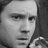

In [10]:
# Display the first image in the dataset
dataset[0]["file"]

In [11]:
# Create a list of unique labels in the dataset
labels = dataset.unique("label")
labels

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [12]:
# Initializing the label2id and id2label dictionaries
label2id, id2label = dict(), dict()

for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

pp(id2label)
print("\n")
pp(label2id)

{0: 'angry',
 1: 'disgust',
 2: 'fear',
 3: 'happy',
 4: 'neutral',
 5: 'sad',
 6: 'surprise'}


{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}


In [13]:
class_label = ClassLabel(num_classes=len(labels), names=labels)

dataset = dataset.map(
    lambda x: {"label": class_label.str2int(x["label"])}, batched=True
)
dataset = dataset.cast_column("label", class_label)

Map:   0%|          | 0/62923 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/62923 [00:00<?, ? examples/s]

In [14]:
# 80% of the data will be used for training and the remaining 20% will be used for validation
dataset = dataset.train_test_split(
    test_size=0.2, shuffle=True, stratify_by_column="label"
)

train_ds, test_ds = dataset["train"], dataset["test"]

## Define the pre-trained ViT model


In [15]:
# Using ViT model of Google
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224", num_labels=len(labels)
)
model.config.id2label = id2label
model.config.label2id = label2id
print(model.num_parameters(only_trainable=True))

# Retrieve the image mean and std used for normalization
image_mean, image_std = processor.image_mean, processor.image_std

# Get the size (height) of the ViT model's input images
size = processor.size["height"]
print(f"Image size = {size} x {size}")

RuntimeError: Error(s) in loading state_dict for ViTForImageClassification:
	size mismatch for classifier.weight: copying a param with shape torch.Size([1000, 768]) from checkpoint, the shape in current model is torch.Size([7, 768]).
	size mismatch for classifier.bias: copying a param with shape torch.Size([1000]) from checkpoint, the shape in current model is torch.Size([7]).
	You may consider adding `ignore_mismatched_sizes=True` in the model `from_pretrained` method.

In [ ]:
# Define a set of transformations to be applied to the input images

train_transforms = Compose(
    [
        Resize((size, size)),
        RandomRotation(45),
        RandomHorizontalFlip(0.5),
        RandomResizedCrop(size, scale=(0.08, 0.5)),
        RandomVerticalFlip(0.5),
        ToTensor(),
        Normalize(image_mean, image_std),
    ]
)

test_transforms = Compose(
    [
        Resize((size, size)),
        ToTensor(),
        Normalize(image_mean, image_std),
    ]
)

In [ ]:
# Applied transformations to the input images
train_ds.set_transform(train_transforms)
test_ds.set_transform(test_transforms)